Tugas 3
Nama: Siti Azimah Izzana
NPM: 2505060013

In [2]:
#membangun hdfs
!hdfs dfs -mkdir -p /user/Azimah/ecommerce/raw
!hdfs dfs -mkdir -p /user/Azimah/ecommerce/processed
!hdfs dfs -ls /user/Azimah/ecommerce

Found 2 items
drwxr-xr-x   - Azimah supergroup          0 2026-09-06 05:58 /user/Azimah/ecommerce/processed
drwxr-xr-x   - Azimah supergroup          0 2026-09-06 05:58 /user/Azimah/ecommerce/raw


In [3]:
#menggungah data mentah
!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/Azimah/ecommerce/raw
!hdfs dfs -ls /user/Azimah/ecommerce/raw

Found 3 items
-rw-r--r--   1 Azimah supergroup      12329 2026-09-06 06:04 /user/Azimah/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 Azimah supergroup      12154 2026-09-06 06:04 /user/Azimah/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 Azimah supergroup      12684 2026-09-06 06:04 /user/Azimah/ecommerce/raw/transaksi_yogyakarta.csv


In [6]:
#Mengunduh ketiga berkas
!hdfs dfs -get /user/Azimah/ecommerce/raw/transaksi_magelang.csv magelang_dari_hdfs.csv
!hdfs dfs -get /user/Azimah/ecommerce/raw/transaksi_semarang.csv semarang_dari_hdfs.csv
!hdfs dfs -get /user/Azimah/ecommerce/raw/transaksi_yogyakarta.csv yogyakarta_dari_hdfs.csv

In [7]:
import pandas as pd
df_magelang = pd.read_csv("magelang_dari_hdfs.csv")
df_semarang = pd.read_csv("semarang_dari_hdfs.csv")
df_yogyakarta = pd.read_csv("yogyakarta_dari_hdfs.csv")

#gabungkan ketiga data frame
df_gabungan = pd.concat([df_magelang, df_semarang, df_yogyakarta], ignore_index=True)
df_gabungan

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang
...,...,...,...,...,...,...,...
595,YOG-2195,2026-08-25,Rumah Tangga,4,250000,Kartu Kredit,Yogyakarta
596,YOG-2196,2026-08-18,Fashion,1,150000,COD,Yogyakarta
597,YOG-2197,2026-08-27,Makanan & Minuman,4,25000,Kartu Kredit,Yogyakarta
598,YOG-2198,2026-08-07,Rumah Tangga,1,25000,COD,Yogyakarta


In [8]:
df_gabungan["kota"].value_counts()

kota
Magelang      200
Semarang      200
Yogyakarta    200
Name: count, dtype: int64

In [9]:
#menambah kolom total_pendapatan
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]
df_gabungan.head()

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000


In [10]:
#tabel ringkasan
ringkasan_kota_kategori = df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"].sum().reset_index()
ringkasan_kota_kategori

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000


In [12]:
#menyimpan dua berkas di disk lokal
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)
print("Kedua berkas berhasil disimpan di disk lokal.")

Kedua berkas berhasil disimpan di disk lokal.


In [13]:
#mengunggah kedua berkas hasil olahan
!hdfs dfs -put data_gabungan_bersih.csv /user/Azimah/ecommerce/processed
!hdfs dfs -put ringkasan_kota_kategori.csv /user/Azimah/ecommerce/processed

#membuktikan kedua berkas berhasil terunggah
!hdfs dfs -ls /user/Azimah/ecommerce/processed

Found 2 items
-rw-r--r--   1 Azimah supergroup      41257 2026-09-06 06:54 /user/Azimah/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 Azimah supergroup        530 2026-09-06 06:54 /user/Azimah/ecommerce/processed/ringkasan_kota_kategori.csv


Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?
menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS mempunyai banyak keuntungan. 
    Pertama, data asli raw akan tetap utuh dan tidak berubah sama sekali, jadi semisal saat mengelola lalu datanya salah, maka masih bisa mengulang dan tidak akan kelihatan data aslinya.
    Kedua, terlihat jelas mana data yang belum diolah dan yang sudah diolah untuk analis.
    Ketiga, jika semua data di campur dalam satu folder maka akan sulit untuk mengatur aksesdata tersebut, data olahan akan jauh lebih aman. 
    Keempat, jika ada perubahan untuk mengelola data, maka cukup mengulang prosesnya tanpa perlu mengambil data lagi.
    Semua ini sangat menghemat waktu dan menjaga seluruh sistem secara optimal demi jangka waktu yang panjang



In [14]:
#mengcek ukuran total disk
!hdfs dfs -du -h /user/Azimah/ecommerce

#menghitung jumlah file & folder di dalamnya
!hdfs dfs -count /user/Azimah/ecommerce

40.8 K  40.8 K  /user/Azimah/ecommerce/processed
36.3 K  36.3 K  /user/Azimah/ecommerce/raw
           3            5              78954 /user/Azimah/ecommerce


In [15]:
#melihat 5 baris pertama, tanpa didownload
!hdfs dfs -cat /user/Azimah/ecommerce/processed/ringkasan_kota_kategori.csv | head -5

kota,kategori,total_pendapatan
Magelang,Elektronik,18775000
Magelang,Fashion,27750000
Magelang,Kesehatan & Kecantikan,17375000
Magelang,Makanan & Minuman,17525000


In [20]:
#melihat detail block dan replication factor dari salah satu file
!hdfs fsck /user/Azimah/ecommerce/raw/transaksi_magelang.csv -files -blocks

Connecting to namenode via http://localhost:9870/fsck?ugi=Azimah&files=1&blocks=1&path=%2Fuser%2FAzimah%2Fecommerce%2Fraw%2Ftransaksi_magelang.csv
FSCK started by Azimah (auth:SIMPLE) from /127.0.0.1 for path /user/Azimah/ecommerce/raw/transaksi_magelang.csv at Sun Sep 06 07:45:43 UTC 2026

/user/Azimah/ecommerce/raw/transaksi_magelang.csv 12329 bytes, replicated: replication=1, 1 block(s):  OK
0. BP-1318551212-10.0.2.15-1788608539636:blk_1073741828_1004 len=12329 Live_repl=1


Status: HEALTHY
 Number of data-nodes:	1
 Number of racks:		1
 Total dirs:			0
 Total symlinks:		0

Replicated Blocks:
 Total size:	12329 B
 Total files:	1
 Total blocks (validated):	1 (avg. block size 12329 B)
 Minimally replicated blocks:	1 (100.0 %)
 Over-replicated blocks:	0 (0.0 %)
 Under-replicated blocks:	0 (0.0 %)
 Mis-replicated blocks:		0 (0.0 %)
 Default replication factor:	1
 Average block replication:	1.0
 Missing blocks:		0
 Corrupt blocks:		0
 Missing replicas:		0 (0.0 %)
 Blocks queued for replic

In [19]:
#melihat status keseluruhan cluster HDFS
!hdfs dfsadmin -report

Configured Capacity: 52652797952 (49.04 GB)
Present Capacity: 24466427904 (22.79 GB)
DFS Remaining: 24466259968 (22.79 GB)
DFS Used: 167936 (164 KB)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	Missing blocks (with replication factor 1): 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0
Erasure Coded Block Groups: 
	Low redundancy block groups: 0
	Block groups with corrupt internal blocks: 0
	Missing block groups: 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0

-------------------------------------------------
Live datanodes (1):

Name: 127.0.0.1:9866 (localhost.localdomain)
Hostname: Azimah
Decommission Status : Normal
Configured Capacity: 52652797952 (49.04 GB)
DFS Used: 167936 (164 KB)
Non DFS Used: 25485402112 (23.74 GB)
DFS Remaining: 24466259968 (22.79 GB)
DFS Used%: 0.00%
DFS Remaining%: 46.47%
Configured Cache Capacity: 0 (0 B)

In [21]:
#melihat info detail: waktu modifikasi, ukuran, replication, block size
!hdfs dfs -stat "%n | Ukuran: %b bytes | Replikasi: %r | Terakhir diubah: %y" /user/Azimah/ecommerce/raw/transaksi_magelang.csv

transaksi_magelang.csv | Ukuran: 12329 bytes | Replikasi: 1 | Terakhir diubah: 2026-09-06 06:04:48


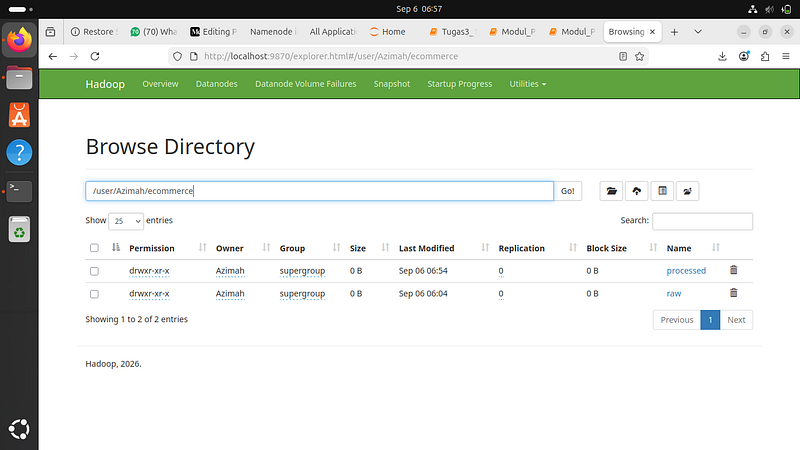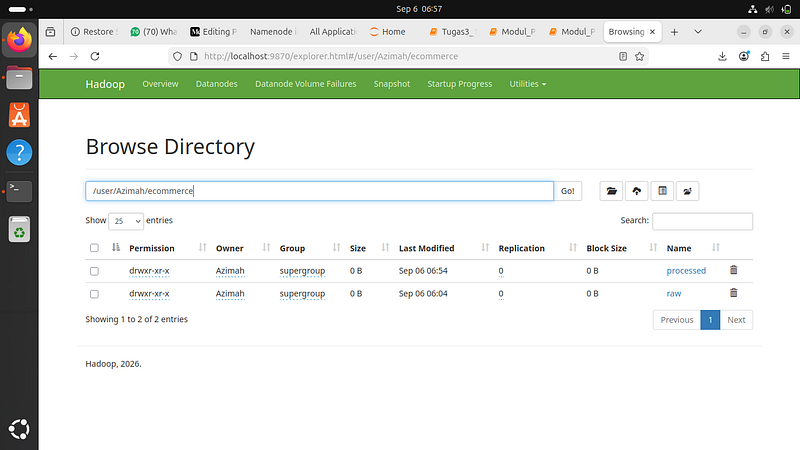

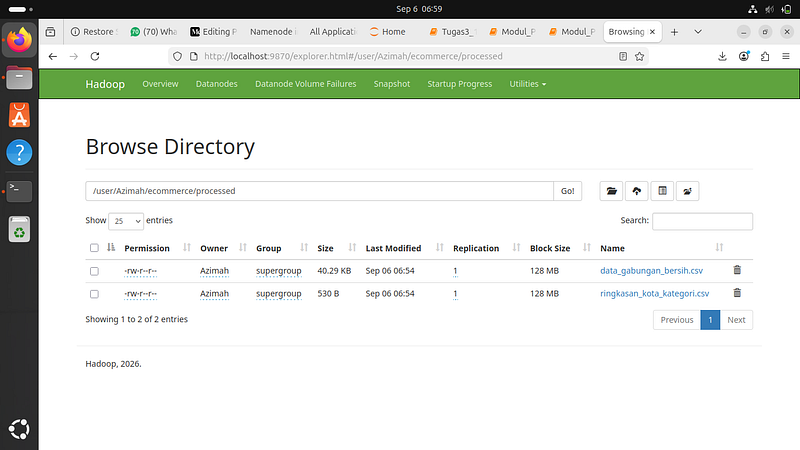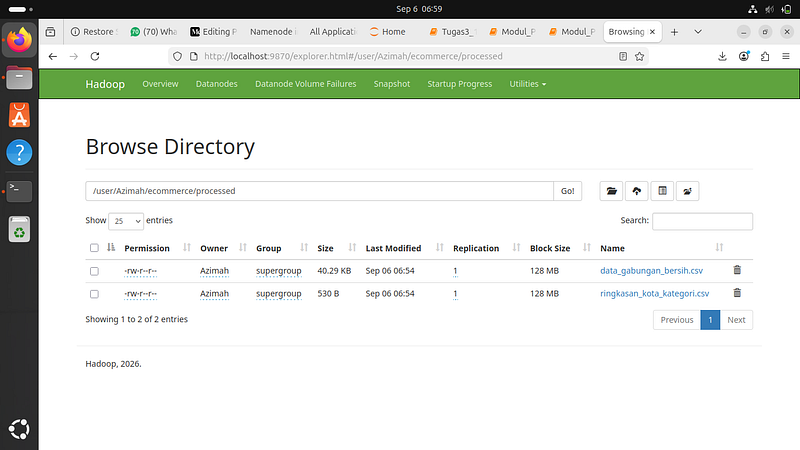

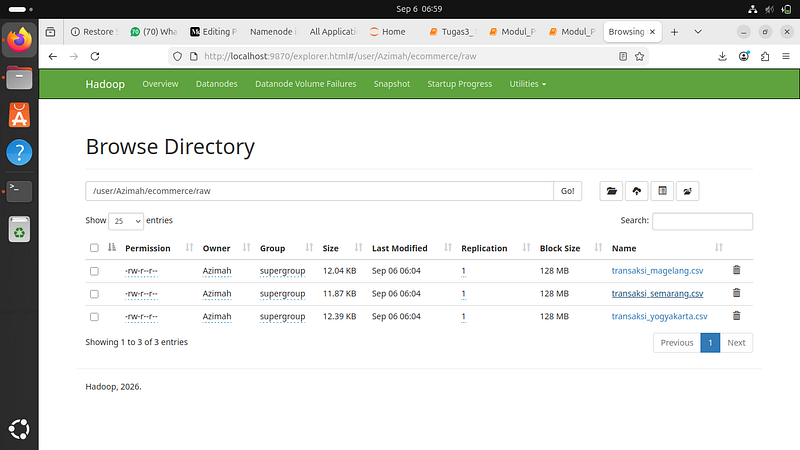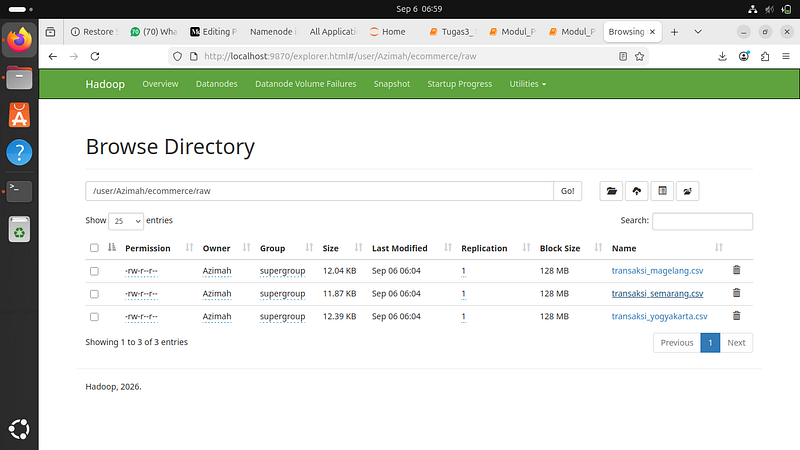